<a href="https://colab.research.google.com/github/04suman/sumanamit/blob/main/ResNet_34_Binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import PIL
import cv2
import tensorflow as tf
from tensorflow import keras

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os


In [ ]:
good=os.listdir("/content/drive/MyDrive/mydata/train/0/")

In [ ]:
b4=os.listdir("/content/drive/MyDrive/mydata/train/3/")


In [ ]:
bad=b4[:1000]

In [ ]:
x1=[]
y1=[]
for i in good[:800]:
    x=cv2.imread(str("/content/drive/MyDrive/mydata/train/0/"+i))
    x1.append(x)
    y1.append(1)


In [ ]:
print(x1[1])

[[[135 135 135]
  [134 134 134]
  [135 135 135]
  ...
  [180 180 180]
  [179 179 179]
  [176 176 176]]

 [[135 135 135]
  [135 135 135]
  [135 135 135]
  ...
  [180 180 180]
  [179 179 179]
  [176 176 176]]

 [[135 135 135]
  [136 136 136]
  [136 136 136]
  ...
  [179 179 179]
  [178 178 178]
  [177 177 177]]

 ...

 [[ 67  67  67]
  [ 68  68  68]
  [ 69  69  69]
  ...
  [170 170 170]
  [168 168 168]
  [164 164 164]]

 [[ 66  66  66]
  [ 67  67  67]
  [ 70  70  70]
  ...
  [168 168 168]
  [166 166 166]
  [164 164 164]]

 [[ 67  67  67]
  [ 68  68  68]
  [ 71  71  71]
  ...
  [168 168 168]
  [166 166 166]
  [163 163 163]]]


In [ ]:
x2=[]
y2=[]
for i in bad[:800]:
    x=cv2.imread(str("/content/drive/MyDrive/mydata/train/3/"+i))
    x2.append(x)
    y2.append(0)

xdata=x1+x2
ydata=y1+y2

In [ ]:
xdata=np.array(xdata)
ydata=np.array(ydata)
xdata=xdata/255
ydata

array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
'''IMG_SIZE=(224,224,)
vgg16_weight_path = '../input/vgg19/vgg19_weights_tf_dim_ordering_tf_kernels_notop.h5'
base_model = tf.keras.applications.VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)
model19 = tf.keras.models.Sequential()
model19.add(base_model)
model19.add(tf.keras.layers.Flatten())
model19.add(tf.keras.layers.Dropout(0.5))
model19.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model19.layers[0].trainable = False
model19.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)
model19.summary()'''

"IMG_SIZE=(224,224,)\nvgg16_weight_path = '../input/vgg19/vgg19_weights_tf_dim_ordering_tf_kernels_notop.h5'\nbase_model = tf.keras.applications.VGG19(\n    weights='imagenet',\n    include_top=False,\n    input_shape=IMG_SIZE + (3,)\n)\nmodel19 = tf.keras.models.Sequential()\nmodel19.add(base_model)\nmodel19.add(tf.keras.layers.Flatten())\nmodel19.add(tf.keras.layers.Dropout(0.5))\nmodel19.add(tf.keras.layers.Dense(1, activation='sigmoid'))\nmodel19.layers[0].trainable = False\nmodel19.compile(\n    loss='binary_crossentropy',\n    optimizer=tf.keras.optimizers.Adam(),\n    metrics=['accuracy']\n)\nmodel19.summary()"

In [ ]:
# prompt: vgg16_weight_path = '../input/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5' base_model = tf.keras.applications.VGG16(     weights=vgg16_weight_path,     include_top=False,     input_shape=IMG_SIZE + (3,) )  model = tf.keras.models.Sequential() model.add(base_model) model.add(tf.keras.layers.Flatten()) model.add(tf.keras.layers.Dropout(0.5)) model.add(tf.keras.layers.Dense(1, activation='sigmoid'))  model.layers[0].trainable = False  model.compile(     loss='binary_crossentropy',     optimizer=tf.keras.optimizers.Adam(),     metrics=['accuracy'] )  model  .summary()
'''IMG_SIZE=(224,224,)
vgg16_weight_path = '../input/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5'
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)
model = tf.keras.models.Sequential()
model.add(base_model)
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model.layers[0].trainable = False
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)
model.summary()'''


"IMG_SIZE=(224,224,)\nvgg16_weight_path = '../input/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5'\nbase_model = tf.keras.applications.VGG16(\n    weights='imagenet',\n    include_top=False,\n    input_shape=IMG_SIZE + (3,)\n)\nmodel = tf.keras.models.Sequential()\nmodel.add(base_model)\nmodel.add(tf.keras.layers.Flatten())\nmodel.add(tf.keras.layers.Dropout(0.5))\nmodel.add(tf.keras.layers.Dense(1, activation='sigmoid'))\nmodel.layers[0].trainable = False\nmodel.compile(\n    loss='binary_crossentropy',\n    optimizer=tf.keras.optimizers.Adam(),\n    metrics=['accuracy']\n)\nmodel.summary()"

In [ ]:
def convolutional_block(x, filter):
    # copy tensor to variable called x_skip
    x_skip = x
    # Layer 1
    x = tf.keras.layers.Conv2D(filter, (3,3), padding = 'same', strides = (2,2))(x)
    x = tf.keras.layers.BatchNormalization(axis=3)(x)
    x = tf.keras.layers.Activation('relu')(x)
    # Layer 2
    x = tf.keras.layers.Conv2D(filter, (3,3), padding = 'same')(x)
    x = tf.keras.layers.BatchNormalization(axis=3)(x)
    # Processing Residue with conv(1,1)
    x_skip = tf.keras.layers.Conv2D(filter, (1,1), strides = (2,2))(x_skip)
    # Add Residue
    x = tf.keras.layers.Add()([x, x_skip])
    x = tf.keras.layers.Activation('relu')(x)
    return x
def identity_block(x, filter):
    # copy tensor to variable called x_skip
    x_skip = x
    # Layer 1
    x = tf.keras.layers.Conv2D(filter, (3,3), padding = 'same')(x)
    x = tf.keras.layers.BatchNormalization(axis=3)(x)
    x = tf.keras.layers.Activation('relu')(x)
    # Layer 2
    x = tf.keras.layers.Conv2D(filter, (3,3), padding = 'same')(x)
    x = tf.keras.layers.BatchNormalization(axis=3)(x)
    # Add Residue
    x = tf.keras.layers.Add()([x, x_skip])
    x = tf.keras.layers.Activation('relu')(x)
    return x

In [ ]:
def ResNet34(shape = (224, 224, 3), classes = 200):
    # Step 1 (Setup Input Layer)
    x_input = tf.keras.layers.Input(shape)
    x = tf.keras.layers.ZeroPadding2D((3, 3))(x_input)
    # Step 2 (Initial Conv layer along with maxPool)
    x = tf.keras.layers.Conv2D(64, kernel_size=7, strides=2, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding='same')(x)
    # Define size of sub-blocks and initial filter size
    block_layers = [3, 4, 6, 3]
    filter_size = 64
    # Step 3 Add the Resnet Blocks
    for i in range(4):
        if i == 0:
            # For sub-block 1 Residual/Convolutional block not needed
            for j in range(block_layers[i]):
                x = identity_block(x, filter_size)
        else:
            # One Residual/Convolutional Block followed by Identity blocks
            # The filter size will go on increasing by a factor of 2
            filter_size = filter_size*2
            x = convolutional_block(x, filter_size)
            for j in range(block_layers[i] - 1):
                x = identity_block(x, filter_size)
    # Step 4 End Dense Network
    x = tf.keras.layers.AveragePooling2D((2,2), padding = 'same')(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation = 'relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Dense(classes, activation = 'sigmoid')(x)
    model = tf.keras.models.Model(inputs = x_input, outputs = x, name = "ResNet34")
    return model


In [ ]:
model=ResNet34()

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(xdata,ydata,test_size=0.2,random_state=43)

In [ ]:
model.compile(
    loss='SparseCategoricalCrossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [ ]:
history=model.fit(xtrain,ytrain,epochs=50)

Epoch 1/50
39/39 [==============================] - 35s 270ms/step - loss: 3.7397 - accuracy: 0.5084
Epoch 2/50
39/39 [==============================] - 8s 201ms/step - loss: 1.2469 - accuracy: 0.5092
Epoch 3/50
39/39 [==============================] - 8s 199ms/step - loss: 1.1133 - accuracy: 0.4892
Epoch 4/50
39/39 [==============================] - 8s 202ms/step - loss: 0.8452 - accuracy: 0.5157
Epoch 5/50
39/39 [==============================] - 8s 203ms/step - loss: 0.8130 - accuracy: 0.5052
Epoch 6/50
39/39 [==============================] - 8s 205ms/step - loss: 0.7463 - accuracy: 0.5205
Epoch 7/50
39/39 [==============================] - 8s 206ms/step - loss: 0.7389 - accuracy: 0.5269
Epoch 8/50
39/39 [==============================] - 8s 203ms/step - loss: 0.6969 - accuracy: 0.5574
Epoch 9/50
39/39 [==============================] - 8s 204ms/step - loss: 0.6796 - accuracy: 0.5767
Epoch 10/50
39/39 [==============================] - 8s 201ms/step - loss: 0.6482 - accuracy: 0.632

In [ ]:
model.evaluate(xtest,ytest)

10/10 [==============================] - 2s 157ms/step - loss: 0.5379 - accuracy: 0.8397


[0.5378552079200745, 0.8397436141967773]

In [ ]:
'''history=model.fit(xtrain,ytrain,epochs=100)

SyntaxError: incomplete input (<ipython-input-45-ca770e14381f>, line 1)

In [ ]:
from sklearn.metrics import precision_score, \
    recall_score, confusion_matrix, classification_report, \
    accuracy_score, f1_score

In [ ]:
ypred=model.predict(xtest)
yp=[1 if x>0.5 else 0 for x in ypred]

10/10 [==============================] - 1s 71ms/step


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(ytest,yp)*100

82.37179487179486

In [ ]:
yp[:5]

In [ ]:
print ('F1 score:', f1_score(ytest, yp)*100)
print ('Recall:', recall_score(ytest, yp)*100)
print ('Precision:', precision_score(ytest, yp)*100)
print ('\n clasification report:\n', classification_report(ytest, yp)*100)
print ('\n confussion matrix:\n',confusion_matrix(ytest, yp)*100)

F1 score: 84.41926345609065
Recall: 92.54658385093167
Precision: 77.60416666666666

 clasification report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80       151
           1       0.78      0.93      0.84       161

    accuracy                           0.82       312
   macro avg       0.84      0.82      0.82       312
weighted avg       0.84      0.82      0.82       312
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       151
           1       0.78      0.93      0.84       161

    accuracy                           0.82       312
   macro avg       0.84      0.82      0.82       312
weighted avg       0.84      0.82      0.82       312
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       151
           1       0.78      0.93      0.84       161

    accuracy                           0.82       312
   macro avg       0.8

In [ ]:
(11700+15300)/(3400+800+11700+15300)

In [ ]:
loss_list=history.history['loss']
acc_list=history.history['accuracy']

epoch_list=[i for i in range(50)]

In [ ]:
import matplotlib.pyplot as plt

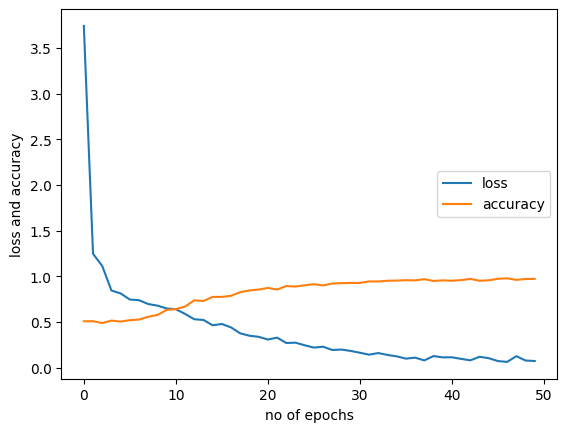

In [ ]:
plt.ylabel('loss and accuracy')
plt.xlabel('no of epochs')
plt.plot(epoch_list,loss_list)
plt.plot(epoch_list,acc_list)
plt.legend(['loss','accuracy'],loc='center right')

plt.show()


In [ ]:
history19=model19.fit(xtrain,ytrain,epochs=10)